## Scenario

Patient comes →
Check BMI →
Route to different treatment paths:

BMI < 18.5 → Nutrition Plan (Underweight)
18.5–25 → Maintain Plan (Normal)
25–30 → Exercise Plan (Overweight)

30 → Medical Plan (Obese)

# Workflow
Start → Calculate BMI → Decision
        → Nutrition Plan
        → Maintain Plan
        → Exercise Plan
        → Medical Plan

In [1]:
# 1: Define State
from typing import TypedDict

class HealthState(TypedDict):
    weight: float
    height: float
    bmi: float
    plan: str

In [2]:
# 2: Node → Calculate BMI

def calculate_bmi(state: HealthState) -> HealthState:
    state["bmi"] = state["weight"] / (state["height"] ** 2)
    return state

In [3]:
# 3: Decision Function (Multi-Path)

def decide_path(state: HealthState) -> str:
    bmi = state["bmi"]
    
    if bmi < 18.5:
        return "nutrition_node"
    elif 18.5 <= bmi < 25:
        return "maintain_node"
    elif 25 <= bmi < 30:
        return "exercise_node"
    else:
        return "medical_node"

In [4]:
# 4: Different Plan Nodes

def nutrition_plan(state: HealthState) -> HealthState:
    state["plan"] = "High calorie diet"
    return state

def maintain_plan(state: HealthState) -> HealthState:
    state["plan"] = "Maintain healthy lifestyle"
    return state

def exercise_plan(state: HealthState) -> HealthState:
    state["plan"] = "Regular exercise + balanced diet"
    return state

def medical_plan(state: HealthState) -> HealthState:
    state["plan"] = "Consult doctor + strict diet"
    return state

In [5]:
# 5: Build Graph
from langgraph.graph import StateGraph, START, END

builder = StateGraph(HealthState)

builder.add_node("bmi_node", calculate_bmi)
builder.add_node("nutrition_node", nutrition_plan)
builder.add_node("maintain_node", maintain_plan)
builder.add_node("exercise_node", exercise_plan)
builder.add_node("medical_node", medical_plan)

builder.add_edge(START, "bmi_node")

# Multi-path routing
builder.add_conditional_edges(
    "bmi_node",
    decide_path,
    {
        "nutrition_node": "nutrition_node",
        "maintain_node": "maintain_node",
        "exercise_node": "exercise_node",
        "medical_node": "medical_node"
    }
)

# End all paths
builder.add_edge("nutrition_node", END)
builder.add_edge("maintain_node", END)
builder.add_edge("exercise_node", END)
builder.add_edge("medical_node", END)

graph = builder.compile()

c:\Users\User\Desktop\vccodepy\.venv\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


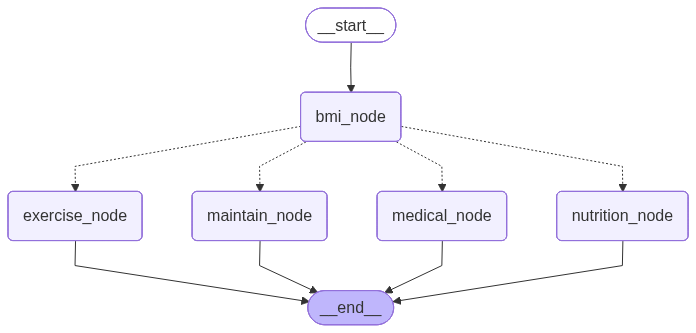

In [6]:
# 6: Visualize Graph
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [7]:
# 7: Example

result = graph.invoke({
    "weight": 95,
    "height": 1.7
})

print(result)

{'weight': 95, 'height': 1.7, 'bmi': 32.871972318339104, 'plan': 'Consult doctor + strict diet'}
